# 06 · Monthly cards — M2 or the latest walk?

## Executive summary (read this first)

Four visible cards (and possibly more hidden ones) use **monthly** data: `t2-F1-cpi-glidepath-2023`,
`t2-F1-sahm-watch-2024`, `t2-F4-covid-nfp-2020`, `t2-F4-cpi-vintage-2022`. Earlier, M2 beat the *old* walk on
all four. The walk has since improved (Student-t shocks; EWMA sd on F4). This notebook decides which model runs
monthly cards in the main model:

- **M2** — `m2_unit.fit_m2(cell, origin=...)`: fitted at each date only on rows whose outcome was known by then
  (the same as f1_pipeline notebook 03), drawn with `m2_unit.draw_joint`.
- **the latest walk** — the card's family setting from notebook 05 (window / widen / Student-t ν / EWMA).

Both are scored with the card's own score (raw), on **the same dates**: every date of each block where M2 has at
least 60 months of training rows (notebook 03's floor for monthly panels).

**The rule, fixed before looking:** the choice is made on **validation**, pooled over the four cards (it is a rule
for monthly cards in general): geometric mean of (M2 score ÷ walk score) below 1 → M2 runs monthly cards;
otherwise the latest walk runs every card. **Test** is opened once, afterwards.

## 0 — Setup

In [1]:
import json, pathlib, sys, time, tomllib
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt

HERE = pathlib.Path.cwd() if pathlib.Path.cwd().name == "model_baseline" else pathlib.Path.cwd() / "model_baseline"
REPO, DATA, UNITS = HERE.parent, HERE / "data", HERE.parent / "units"
for p in (str(REPO), str(REPO / "f1_pipeline")):
    if p not in sys.path: sys.path.insert(0, p)
import forecast_agent as fa
import m2_unit as m2

pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
M2_C, WALK_C = "#1baf7a", "#eb6834"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "axes.axisbelow": True, "grid.color": GRID, "axes.edgecolor": INK2,
                     "axes.titlelocation": "left", "legend.frameon": False, "font.size": 10})
geo = lambda r: float(np.exp(np.log(np.asarray(r, float)).mean()))

TARGETS = pd.read_parquet(DATA / "targets.parquet")
STEPS = pd.read_parquet(DATA / "steps.parquet")
cards_csv = pd.read_csv(DATA / "cards.csv", index_col=0)
MONTHLY = sorted(cards_csv.index[cards_csv.freq.str.contains("monthly")])
CARDS = {u: tomllib.loads((UNITS / u / "card.toml").read_text()) for u in MONTHLY}

def parse(label):                                   # "260 / 1.2 / ν=5 / EWMA hl=63" -> settings dict
    w, wd, shape, vol = [x.strip() for x in str(label).split("/")]
    return {"window": int(w), "widen": float(wd), "nu": None if shape == "normal" else int(shape.split("=")[1]),
            "halflife": None if vol == "window sd" else int(vol.split("=")[1])}

latest = pd.read_csv(DATA / "ewma_settings.csv", index_col=0)["final"]
WALK = {u: parse(latest[u]) for u in MONTHLY}
MIN_TRAIN_ROWS = 60
print("monthly cards and the latest walk setting of their family:")
pd.DataFrame({u: {"family": CARDS[u]["metadata"]["category"], "walk setting": latest[u]} for u in MONTHLY}).T

monthly cards and the latest walk setting of their family:


,family,walk setting
t2-F1-cpi-glidepath-2023,T2-F1,42 / 1.2 / ν=5 / window sd
t2-F1-sahm-watch-2024,T2-F1,42 / 1.2 / ν=5 / window sd
t2-F4-covid-nfp-2020,T2-F4,260 / 1.2 / ν=5 / EWMA hl=63
t2-F4-cpi-vintage-2022,T2-F4,260 / 1.2 / ν=5 / EWMA hl=63


## 1 — The two models and the score (same functions as notebooks 04–05)

In [2]:
MIN_CHANGES = 10

def ewma_sd(past, halflife):
    age = np.arange(len(past))[::-1]
    w = 0.5 ** (age / halflife); w = w / w.sum()
    mean = w @ past
    return np.sqrt(w @ (past - mean) ** 2)

def walk_forecast(steps, origin, anchor, ksteps, horizons, window=260, widen=1.0, nu=None, halflife=None, n_draws=1000, seed=0):
    i = steps.index.searchsorted(pd.Timestamp(origin), side="right")
    arr = steps.to_numpy(); past = arr[max(0, i - window): i]
    if len(past) < MIN_CHANGES:
        raise ValueError(f"only {len(past)} steps before {origin}")
    n_a = past.shape[1]; D = np.ascontiguousarray(past.T)
    sd = (D.std(axis=1) if halflife is None else ewma_sd(arr[max(0, i - int(8 * halflife)): i], halflife)) * widen
    with np.errstate(invalid="ignore", divide="ignore"):
        corr = np.nan_to_num(np.atleast_2d(np.corrcoef(D)), nan=0.0)
    np.fill_diagonal(corr, 1.0)
    w, v = np.linalg.eigh(corr); corr = v @ np.diag(np.clip(w, 1e-8, None)) @ v.T
    L = np.linalg.cholesky(corr)
    rng, rng_t = np.random.default_rng(seed), np.random.default_rng([seed, 7])
    out = np.empty((n_draws, n_a, len(horizons))); path, prev = np.zeros((n_draws, n_a)), np.zeros(n_a)
    for hi in np.argsort(horizons):
        z = rng.standard_normal((n_draws, n_a)) @ L.T
        rng.standard_normal((n_draws, n_a))
        if nu is not None:
            z = z * np.sqrt((nu - 2.0) / rng_t.chisquare(nu, size=(n_draws, 1)))
        kk = np.asarray(ksteps, float)[:, hi]
        path = path + z * sd * np.sqrt(np.maximum(kk - prev, 0)); prev = kk
        out[:, :, hi] = np.asarray(anchor, float) + path
    return out

from qfbench2_track_forecasting import scoring as S

def card_score(card, samples, y):
    p = card.get("scoring", {}).get("params", {})
    w = p.get("weights", {"marginal": 0.5, "joint": 0.3, "tail": 0.2}); w = (float(w["marginal"]), float(w["joint"]), float(w["tail"]))
    if samples.shape[1] == 1:
        live = w[0] + w[2]; w = (w[0] / live, 0.0, w[2] / live)
    out = S._composite(samples, y, weights=w, tail_levels=tuple(p.get("tail_levels", (0.01, 0.05, 0.95, 0.99))),
                       joint=S.card_joint_statistic(card), tail_metric=str(p.get("tail_metric", S.DEFAULT_TAIL_METRIC)), ref_scale=None)
    q = np.quantile(samples, [0.01, 0.05, 0.25, 0.75, 0.95, 0.99], axis=0)
    inside = lambda lo, hi: float(np.mean((y >= q[lo]) & (y <= q[hi])))
    return {**out, "cov50": inside(2, 3), "cov90": inside(1, 4), "cov98": inside(0, 5)}

## 2 — Backtest the four monthly cards, every date

For each date: M2 fitted on rows known by then (skip the date if M2 has fewer than 60 training rows), the latest
walk on the steps up to then, both 1,000 draws, both scored against the same answer.

In [3]:
rows, t0 = [], time.time()
for u in MONTHLY:
    card = CARDS[u]; t = card["targets"]
    assets, horizons = [str(a) for a in t["asset_ids"]], [int(h) for h in t["horizons"]]
    unit = m2.unit_from_panels(fa._read_panels(UNITS / u), assets, horizons, card["provenance"]["data_cutoff"], t["target_type"])
    cells = m2.build_features(unit)                                           # asset-major, then horizon: card order
    steps = STEPS[STEPS.unit == u].pivot(index="date", columns="asset", values="step")[assets].sort_index()
    tt = TARGETS[TARGETS.unit == u].set_index(["origin_date", "asset", "horizon"]).sort_index()
    for block in ("train", "validation", "test"):
        sub = tt[tt.split == block]
        for j, o in enumerate(np.sort(sub.index.get_level_values(0).unique())):
            r = sub.loc[o]
            anchor = np.array([r.loc[(a, horizons[0]), "anchor"] for a in assets])
            ksteps = np.array([[r.loc[(a, h), "steps"] for h in horizons] for a in assets])
            y = np.array([r.loc[(a, h), "target"] for a in assets for h in horizons])
            try:
                fits = [m2.fit_m2(c, origin=pd.Timestamp(o)) for c in cells]
                if min(f.n_train for f in fits) < MIN_TRAIN_ROWS:
                    continue
                d_m2 = m2.draw_joint(fits, 1000, j)
                d_walk = walk_forecast(steps, o, anchor, ksteps, horizons, seed=j, **WALK[u]).reshape(1000, -1)
            except ValueError:
                continue
            for name, d in (("M2", d_m2), ("walk", d_walk)):
                rows.append({"unit": u, "family": card["metadata"]["category"], "block": block, "origin": o,
                             "model": name, "n_train": min(f.n_train for f in fits), **card_score(card, d, y)})
res = pd.DataFrame(rows)
print(f"{res[res.model == 'M2'].shape[0]} dates scored for each model, in {time.time() - t0:.0f}s")
res[res.model == "M2"].groupby(["unit", "block"]).size().unstack("block")[["train", "validation", "test"]]

713 dates scored for each model, in 2s


block,train,validation,test
unit,,,
t2-F1-cpi-glidepath-2023,37,55,82
t2-F1-sahm-watch-2024,44,57,86
t2-F4-covid-nfp-2020,41,50,72
t2-F4-cpi-vintage-2022,53,56,80


## 3 — Per card and block: M2 ÷ walk (below 1 = M2 better)

In [4]:
w = res.pivot_table(index=["unit", "block", "origin"], columns="model", values="composite").reset_index()
w["ratio"] = w["M2"] / w["walk"]
per = w.groupby(["unit", "block"]).agg(dates=("ratio", "size"), ratio=("ratio", geo), M2_wins=("ratio", lambda r: (r < 1).mean()))
cov = res.groupby(["unit", "block", "model"])[["cov90", "cov98"]].mean().unstack("model")
cov.columns = [f"{a}_{b}" for a, b in cov.columns]
table = per.join(cov).reindex(pd.MultiIndex.from_product([MONTHLY, ["train", "validation", "test"]], names=["unit", "block"]))
display(table.round(3))
pooled = w.groupby("block").ratio.apply(geo).reindex(["train", "validation", "test"])
print("pooled over the 4 cards, M2 ÷ walk:", pooled.round(3).to_dict())

dates  ratio  M2_wins  cov90_M2  cov90_walk  cov98_M2  cov98_walk
unit                     block                                                                        
t2-F1-cpi-glidepath-2023 train          37  0.597    0.757     0.500       0.432     0.676       0.716
                         validation     55  0.634    0.727     0.891       0.636     1.000       0.982
                         test           82  0.421    0.902     0.689       0.146     0.780       0.494
t2-F1-sahm-watch-2024    train          44  1.032    0.591     0.534       0.534     0.682       0.614
                         validation     57  0.722    0.860     0.807       0.833     0.930       1.000
                         test           86  0.523    0.837     0.680       0.890     0.779       0.901
t2-F4-covid-nfp-2020     train          41  0.656    0.780     0.780       0.659     0.854       0.805
                         validation     50  0.588    0.880     0.900       0.980     0.960       1.000
                         test           72  0.351    1.000     0.944       0.903     1.000       1.000
t2-F4-cpi-vintage-2022   train          53  0.675    0.698     0.792       0.736     0.887       0.925
                         validation     56  0.694    0.714     0.893       0.946     0.982       1.000
                         test           80  0.672    0.775     0.788       0.662     0.912       0.850

pooled over the 4 cards, M2 ÷ walk: {'train': 0.727, 'validation': 0.66, 'test': 0.481}


## 4 — The decision, on validation

In [5]:
val = pooled["validation"]
DECISION = "M2" if val < 1.0 else "walk"
print(f"validation, pooled over the 4 monthly cards: M2 ÷ walk = {val:.3f}  ->  monthly cards run {DECISION}")
print(f"test (opened now, after the decision): M2 ÷ walk = {pooled['test']:.3f}  "
      f"({'agrees' if (pooled['test'] < 1) == (val < 1) else 'disagrees'} with the decision)")

validation, pooled over the 4 monthly cards: M2 ÷ walk = 0.660  ->  monthly cards run M2
test (opened now, after the decision): M2 ÷ walk = 0.481  (agrees with the decision)


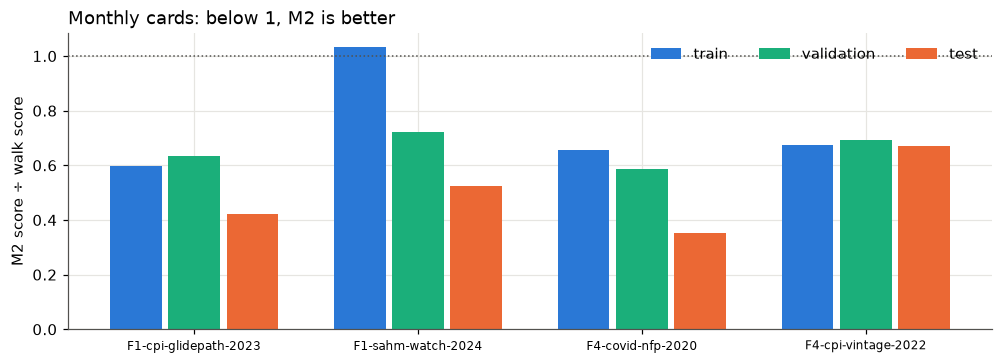

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.2), layout="constrained")
x = np.arange(len(MONTHLY)); wb = 0.26
for j, (b, col) in enumerate((("train", "#2a78d6"), ("validation", M2_C), ("test", WALK_C))):
    ax.bar(x + (j - 1) * wb, [table.loc[(u, b), "ratio"] for u in MONTHLY], width=wb - 0.03, color=col, label=b)
ax.axhline(1, color=INK2, ls=":", lw=1); ax.set_xticks(x, [u.replace("t2-", "") for u in MONTHLY], fontsize=8)
ax.set_ylabel("M2 score ÷ walk score"); ax.legend(ncols=3); ax.set_title("Monthly cards: below 1, M2 is better"); plt.show()

## 5 — Save

In [7]:
res.to_parquet(DATA / "monthly_m2_vs_walk.parquet", index=False)
(DATA / "monthly_decision.json").write_text(json.dumps({"monthly_model": DECISION, "validation_ratio_m2_over_walk": round(val, 4),
                                                        "test_ratio_m2_over_walk": round(float(pooled["test"]), 4),
                                                        "cards": MONTHLY}, indent=2) + "\n")
print((DATA / "monthly_decision.json").read_text())

{
  "monthly_model": "M2",
  "validation_ratio_m2_over_walk": 0.66,
  "test_ratio_m2_over_walk": 0.4813,
  "cards": [
    "t2-F1-cpi-glidepath-2023",
    "t2-F1-sahm-watch-2024",
    "t2-F4-covid-nfp-2020",
    "t2-F4-cpi-vintage-2022"
  ]
}

